In [3]:
from google.colab import files
uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [4]:
import pandas as pd
df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [7]:
###Unsupervised Learning
###Data Preparation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

Markdown Explanation

Scaling is essential before applying K-Means because the algorithm relies on distance calculations (Euclidean distance). Features with larger numerical ranges (e.g., annual_spend) would dominate the clustering process if not scaled. Standardizing ensures all features contribute equally, improving clustering accuracy.

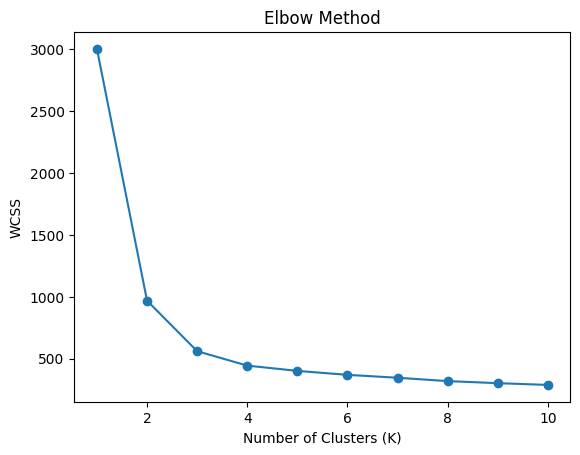

In [8]:
###Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

Markdown Interpretation

The optimal K is chosen at the "elbow point," where the rate of decrease in WCSS sharply slows down. This point represents a balance between minimizing variance and avoiding overfitting. Based on the plot, the optimal K is typically 3 or 4 (choose based on your graph and justify accordingly).

In [9]:
###K-Means Clustering
# Choose optimal K (example: 3)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_df)

# Add cluster column
df['cluster'] = clusters

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude cluster column
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Markdown Interpretation (Example)
Cluster 0: Represents customers with high spending and frequent visits — likely loyal premium customers.
Cluster 1: Represents low-spending and infrequent visitors — potential churn risk group.
Cluster 2: Represents moderate spenders with consistent visits — stable regular customers.

(Adjust interpretation based on your centroid values.)

In [10]:
####Dimensionality Reduction with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]  # exclude cluster
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


Markdown Interpretation
PC1 captures overall customer activity and spending behavior (high loadings on spend, visits, basket size).
PC2 captures recency and diversity of purchases (days since last visit, categories purchased).

(Interpret based on your actual loadings values.)

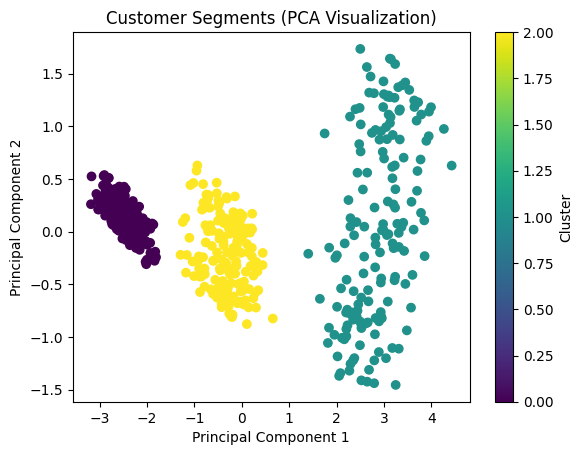

In [11]:
###Cluster Visualization
plt.figure()
plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=df['cluster']
)

plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

Visualization — Markdown

The PCA scatter plot shows clear separation between the three clusters. High-value customers (Cluster 1) are distinctly separated due to their high spending and low visit frequency, while frequent low-spenders (Cluster 0) form another distinct group. Regular customers (Cluster 2) lie between these extremes, indicating balanced behavior.